work flow

1. importing data set
2. data cleaning
3. data analysis
4. data preprocessing
5. train test split
6. model selection & training -> Random forest
7. model evaluation
8. predictive modeling



1. importing data and libraries

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [ ]:
wine_dataset = pd.read_csv('winequality-red.csv')

wine_dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


2. Data cleaning

In [7]:
# checking for missing values
wine_dataset.isnull().sum()

# filling the missing values with mean value
wine_dataset = wine_dataset.fillna(wine_dataset.mean())


3. Data analysis (Exploratory data analysis)

In [ ]:
wine_dataset.shape # number of rows and columns in the dataset

(1599, 12)

In [ ]:
wine_dataset.describe() # statistical measures of the data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


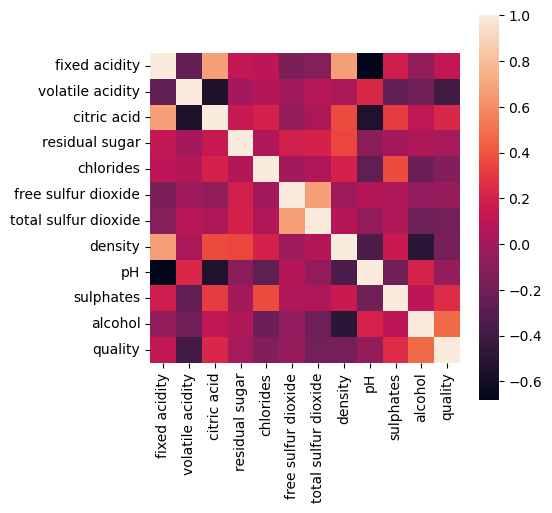

In [12]:
# correlation of data
correlation_matrix = wine_dataset.corr()
plt.figure(figsize=(5,5))
sns.heatmap(correlation_matrix, cbar=True, square=-True)
plt.show()

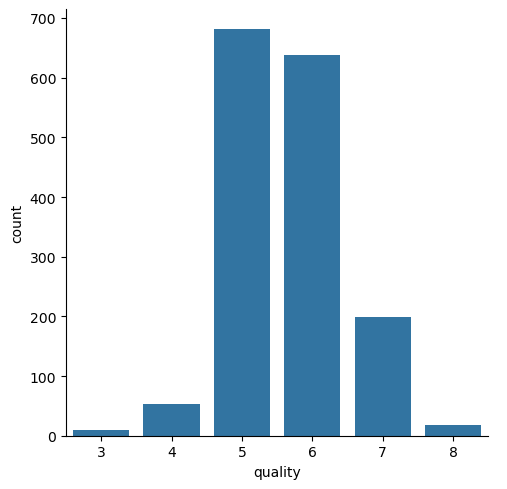

In [13]:
# number of values for each quality
plt.Figure(figsize=(5,5))
sns.catplot(x='quality', data= wine_dataset, kind='count')
plt.show()

4. Data preprocessing

In [15]:
x = wine_dataset.drop('quality', axis=1)
y = wine_dataset['quality'].apply(lambda y_value: 1 if y_value>=7 else 0)

# As this is supervised learning, we will binarize the variable
# good quality = 1, bad quality = 0

print(x)
print(y)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

5. Train test split


In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=23)

6. Model training

In [28]:
model = RandomForestClassifier(criterion='entropy', n_estimators=100, max_depth=3, random_state=23)
model.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=3, random_state=23)

7. model evaluation

In [29]:
test_accuracy = model.score(x_test, y_test)
print('Test accuracy_score: ', test_accuracy)

Test accuracy_score:  0.8875


8. Predictive modeling

In [ ]:
var1 = input('Enter the value of fixed acidity: ')
var2 = input('Enter the value of volatile acidity: ')
var3 = input('Enter the value of citric acid: ')
var4 = input('Enter the value of residual sugar: ')
var5 = input('Enter the value of chlorides: ')
var6 = input('Enter the value of total sulfur dioxide: ')
var7 = input('Enter the value of density: ')
var8 = input('Enter the value of pH: ')
var9 = input('Enter the value of sulphates: ')
var10 = input('Enter the value of alcohol: ')

input_data = np.array([[var1, var2, var3, var4, var5,var6, var7, var8, var9, var10]])

prediction = model.predict(input_data)

if prediction[0] == 1:
    print("The wine is of good quality")
else:
    print("The wine is bad quality")